In [1]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

<Figure size 1200x800 with 0 Axes>

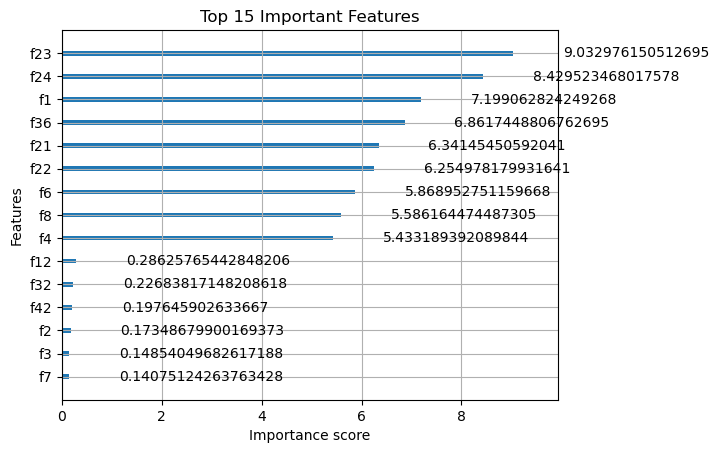

In [4]:
import matplotlib.pyplot as plt
from xgboost import plot_importance
import joblib

best_model = joblib.load(
    r"E:\Smart-Irrigation-System\backend\artifacts\xgboost_model.pkl"
)

plt.figure(figsize=(12,8))
plot_importance(
    best_model,
    importance_type="gain",
    max_num_features=15
)
plt.title("Top 15 Important Features")
plt.show()

In [18]:
preprocessor = joblib.load(
    r"E:\Smart-Irrigation-System\backend\artifacts\preprocessor.pkl"
)
feature_names = preprocessor.get_feature_names_out()

In [20]:

import pandas as pd

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
23,cat__Crop_Growth_Stage_Sowing,0.142097
24,cat__Crop_Growth_Stage_Vegetative,0.132604
1,num__Soil_Moisture,0.113248
36,cat__Mulching_Used_No,0.107941
21,cat__Crop_Growth_Stage_Flowering,0.099757
22,cat__Crop_Growth_Stage_Harvest,0.098396
6,num__Rainfall_mm,0.092324
8,num__Wind_Speed_kmh,0.087875
4,num__Temperature_C,0.085469
12,cat__Soil_Type_Loamy,0.004503


In [15]:
from sklearn.model_selection import RandomizedSearchCV

In [21]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0]
}

In [23]:
from xgboost import XGBClassifier

random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        random_state=42
    ),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="f1_weighted",
    verbose=2,
    n_jobs=-1,
    random_state=42
)

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv(r"E:\Smart-Irrigation-System\data\raw\irrigation_dataset.csv")
X = df.drop(columns=["Irrigation_Need"])
y = LabelEncoder().fit_transform(df["Irrigation_Need"])

X_train, _, y_train, _ = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_processed = preprocessor.transform(X_train)
random_search.fit(
    X_train_processed,
    y_train
)
X_train_processed = preprocessor.transform(X_train)
random_search.fit(
    X_train_processed,
    y_train
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,"XGBClassifier..._class=3, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,20
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [30]:
print(random_search.best_params_)

{'subsample': 0.9, 'n_estimators': 100, 'max_depth': 9, 'learning_rate': 0.2, 'colsample_bytree': 1.0}


In [31]:
print(random_search.best_score_)

0.9953606247138962


In [33]:
best_model = random_search.best_estimator_

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv(r"E:\Smart-Irrigation-System\data\raw\irrigation_dataset.csv")
X = df.drop(columns=["Irrigation_Need"])
y = LabelEncoder().fit_transform(df["Irrigation_Need"])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

random_search.fit(
    X_train_processed,
    y_train
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,"XGBClassifier..._class=3, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,20
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [38]:
from sklearn.metrics import accuracy_score

y_pred_best = best_model.predict(X_test_processed)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_best)
)

Accuracy: 0.996


In [40]:
from sklearn.metrics import accuracy_score, classification_report

label_encoder = joblib.load(
    r"E:\Smart-Irrigation-System\backend\artifacts\label_encoder.pkl"
)

y_pred_best = best_model.predict(X_test_processed)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=label_encoder.classes_
    )
)

Accuracy: 0.996
              precision    recall  f1-score   support

        High       1.00      0.96      0.98        67
         Low       1.00      1.00      1.00      1173
      Medium       0.99      1.00      0.99       760

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000

